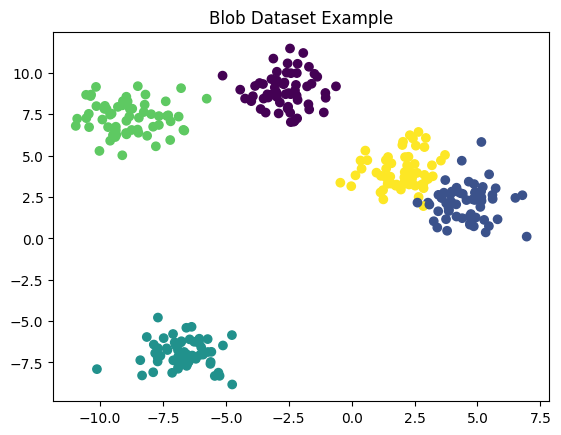

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate a blob dataset with 4 clusters
X, y = make_blobs(n_samples=300, centers=5, cluster_std=1.0, random_state=42)
# print(X)
# print(y)
# Plot the generated points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.title('Blob Dataset Example')
plt.show()

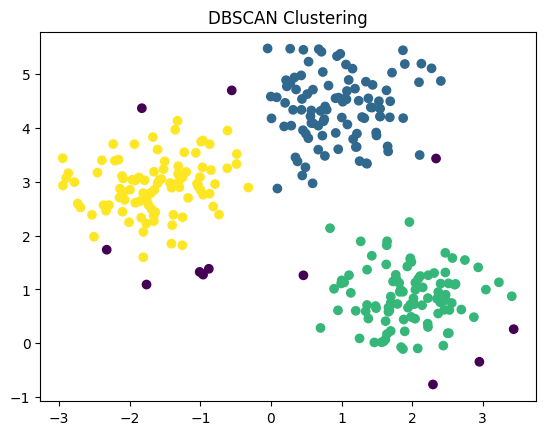

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Generate sample data
X, _ = make_blobs(n_samples=300, cluster_std=0.6, random_state=0)
# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X)
# Plotting the clusters

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.show()



## Apriory Algorithms

In [ ]:
## Apriory algo
!pip install --upgrade mlxtend


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Create the dataset (4 transactions with items)
data = {'Bread': [1, 1, 0, 1],
        'Milk': [1, 0, 1, 1],
        'Diapers': [0, 1, 1, 1],
        'Beer': [0, 1, 1, 0]}

df = pd.DataFrame(data)

# Convert to boolean type (older versions require boolean data)
df = df.astype(bool)

print("Dataset:")
print(df)

# Step 2: Apply the Apriori algorithm with min_support=0.5
frequent_itemsets = apriori(df, min_support=0.5, use_colnames=True)
print("\nFrequent Itemsets:")
print(frequent_itemsets)

# Step 3: Generate association rules with min_confidence=0.6
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6, num_itemsets=len(frequent_itemsets))
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

# Step 4: Print rules in plain language
print("Association Rules with Explanations:\n")
for _, row in rules.iterrows():
    antecedent = ", ".join(list(row['antecedents']))
    consequent = ", ".join(list(row['consequents']))
    confidence = row['confidence'] * 100
    print(f"{antecedent} → {consequent}: If a customer buys {antecedent}, there is a {confidence:.2f}% chance they will also buy {consequent}.")


Dataset:
   Bread   Milk  Diapers   Beer
0   True   True    False  False
1   True  False     True   True
2  False   True     True   True
3   True   True     True  False

Frequent Itemsets:
   support          itemsets
0     0.75           (Bread)
1     0.75            (Milk)
2     0.75         (Diapers)
3     0.50            (Beer)
4     0.50     (Bread, Milk)
5     0.50  (Bread, Diapers)
6     0.50   (Milk, Diapers)
7     0.50   (Diapers, Beer)

Association Rules:
  antecedents consequents  support  confidence      lift
0     (Bread)      (Milk)      0.5    0.666667  0.888889
1      (Milk)     (Bread)      0.5    0.666667  0.888889
2     (Bread)   (Diapers)      0.5    0.666667  0.888889
3   (Diapers)     (Bread)      0.5    0.666667  0.888889
4      (Milk)   (Diapers)      0.5    0.666667  0.888889
5   (Diapers)      (Milk)      0.5    0.666667  0.888889
6   (Diapers)      (Beer)      0.5    0.666667  1.333333
7      (Beer)   (Diapers)      0.5    1.000000  1.333333
Association Rules

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
